<a href="https://colab.research.google.com/github/Omniaaaaaaa/LLSTM/blob/main/LSTM_Numerical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 LSTM Numerical Example — From Scratch

This notebook walks through a **complete LSTM forward pass from scratch** using only NumPy.

**Goal:** Predict the next value in the sequence `[1, 2, 3, 4]` → predict `≈ 3.8`


## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print("Libraries imported ✅")

Libraries imported ✅


## 2. Activation Functions

In [2]:
def sigmoid(x):
    """Sigmoid activation: maps any value to (0, 1)"""
    return 1 / (1 + np.exp(-x))

def tanh(x):
    """Tanh activation: maps any value to (-1, 1)"""
    return np.tanh(x)

# Quick test
print(f"sigmoid(0) = {sigmoid(0):.4f}  (expected 0.5)")
print(f"sigmoid(1) = {sigmoid(1):.4f}")
print(f"tanh(0)    = {tanh(0):.4f}    (expected 0.0)")
print(f"tanh(1)    = {tanh(1):.4f}")

sigmoid(0) = 0.5000  (expected 0.5)
sigmoid(1) = 0.7311
tanh(0)    = 0.0000    (expected 0.0)
tanh(1)    = 0.7616


## 3. Initialize LSTM Parameters

Weights from the PDF example:

| Gate | W (input) | U (hidden) | b (bias) |
|------|-----------|------------|----------|
| Forget | 0.5 | 0.6 | 0.1 |
| Input  | 0.7 | 0.8 | 0.2 |
| Candidate | 0.9 | 1.0 | 0.3 |
| Output | 0.4 | 0.5 | 0.1 |

**Linear output layer:** `Wy = 4.0`, `by = 0.2`

In [3]:
# ── Forget Gate ──────────────────────────────────────
Wf, Uf, bf = 0.5, 0.6, 0.1

# ── Input Gate ───────────────────────────────────────
Wi, Ui, bi = 0.7, 0.8, 0.2

# ── Candidate Cell State ─────────────────────────────
Wc, Uc, bc = 0.9, 1.0, 0.3

# ── Output Gate ──────────────────────────────────────
Wo, Uo, bo = 0.4, 0.5, 0.1

# ── Linear Output Layer ──────────────────────────────
Wy = 4.0   # correct value from PDF
by = 0.2

# ── Initial States ───────────────────────────────────
h0 = 0.0
C0 = 0.0

print("Parameters initialized ✅")
print(f"Initial hidden state h0 = {h0}")
print(f"Initial cell state   C0 = {C0}")
print(f"Output layer: Wy = {Wy}, by = {by}")

Parameters initialized ✅
Initial hidden state h0 = 0.0
Initial cell state   C0 = 0.0
Output layer: Wy = 4.0, by = 0.2


## 4. Input Sequence

In [4]:
inputs = [1, 2, 3, 4]

print(f"Input sequence : {inputs}")
print(f"Goal           : predict the value after 4  (expected approx 3.8)")

Input sequence : [1, 2, 3, 4]
Goal           : predict the value after 4  (expected approx 3.8)


In [5]:
def lstm_step(x, h_prev, C_prev):
    """
    One LSTM time step.

    Args:
        x      : current input
        h_prev : previous hidden state
        C_prev : previous cell state

    Returns:
        h_new, C_new, gates (dict)
    """
    # 1. Forget Gate
    f = sigmoid(Wf * x + Uf * h_prev + bf)

    # 2. Input Gate
    i = sigmoid(Wi * x + Ui * h_prev + bi)

    # 3. Candidate Cell State
    C_tilde = tanh(Wc * x + Uc * h_prev + bc)

    # 4. Cell State Update
    C_new = f * C_prev + i * C_tilde

    # 5. Output Gate
    o = sigmoid(Wo * x + Uo * h_prev + bo)

    # 6. Hidden State Update
    h_new = o * tanh(C_new)

    gates = {
        'f'      : f,
        'i'      : i,
        'C_tilde': C_tilde,
        'C_new'  : C_new,
        'o'      : o,
        'h_new'  : h_new
    }
    return h_new, C_new, gates

print("lstm_step() defined ✅")

lstm_step() defined ✅


## 6. Forward Pass — Step by Step

In [6]:
h, C = 0.0, 0.0

print("=" * 62)
print("        LSTM FORWARD PASS - STEP BY STEP")
print("=" * 62)

for t, x in enumerate(inputs, start=1):
    print(f"\n" + "-"*62)
    print(f"  Time Step t={t}  |  Input x = {x}")
    print("-"*62)

    h_prev, C_prev = h, C
    h, C, gates = lstm_step(x, h, C)

    print(f"  1. Forget Gate   f  = sigmoid({Wf}x{x} + {Uf}x{h_prev:.4f} + {bf}) = {gates['f']:.4f}")
    print(f"  2. Input Gate    i  = sigmoid({Wi}x{x} + {Ui}x{h_prev:.4f} + {bi}) = {gates['i']:.4f}")
    print(f"  3. Candidate     C~ = tanh({Wc}x{x} + {Uc}x{h_prev:.4f} + {bc})   = {gates['C_tilde']:.4f}")
    print(f"  4. Cell State    C  = {gates['f']:.4f}x{C_prev:.4f} + {gates['i']:.4f}x{gates['C_tilde']:.4f} = {gates['C_new']:.4f}")
    print(f"  5. Output Gate   o  = sigmoid({Wo}x{x} + {Uo}x{h_prev:.4f} + {bo}) = {gates['o']:.4f}")
    print(f"  6. Hidden State  h  = {gates['o']:.4f} x tanh({gates['C_new']:.4f})          = {gates['h_new']:.4f}")

print(f"\n" + "="*62)
print(f"  Final hidden state  h = {h:.4f}")
print(f"  Final cell state    C = {C:.4f}")
print("="*62)

        LSTM FORWARD PASS - STEP BY STEP

--------------------------------------------------------------
  Time Step t=1  |  Input x = 1
--------------------------------------------------------------
  1. Forget Gate   f  = sigmoid(0.5x1 + 0.6x0.0000 + 0.1) = 0.6457
  2. Input Gate    i  = sigmoid(0.7x1 + 0.8x0.0000 + 0.2) = 0.7109
  3. Candidate     C~ = tanh(0.9x1 + 1.0x0.0000 + 0.3)   = 0.8337
  4. Cell State    C  = 0.6457x0.0000 + 0.7109x0.8337 = 0.5927
  5. Output Gate   o  = sigmoid(0.4x1 + 0.5x0.0000 + 0.1) = 0.6225
  6. Hidden State  h  = 0.6225 x tanh(0.5927)          = 0.3310

--------------------------------------------------------------
  Time Step t=2  |  Input x = 2
--------------------------------------------------------------
  1. Forget Gate   f  = sigmoid(0.5x2 + 0.6x0.3310 + 0.1) = 0.7856
  2. Input Gate    i  = sigmoid(0.7x2 + 0.8x0.3310 + 0.2) = 0.8659
  3. Candidate     C~ = tanh(0.9x2 + 1.0x0.3310 + 0.3)   = 0.9846
  4. Cell State    C  = 0.7856x0.5927 + 0.8659x

## 7. Final Prediction — Linear Layer

$$\hat{y} = W_y \cdot h + b_y = 4.0 \times h + 0.2$$

In [13]:
y_pred = Wy * h + by

print("=" * 42)
print("        FINAL PREDICTION")
print("=" * 42)
print(f"  y_hat = Wy x h + by")
print(f"        = {Wy} x {h:.4f} + {by}")
print(f"        = {y_pred:.4f}")
print()
print(f"  Predicted  = {y_pred:.2f}")
print(f"  Actual     = 4")
print("=" * 42)

        FINAL PREDICTION
  y_hat = Wy x h + by
        = 4.0 x 0.8863 + 0.2
        = 3.7453

  Predicted  = 3.75
  Actual     = 4


## 8. Summary Table

In [14]:
h, C = 0.0, 0.0
rows = []

for t, x in enumerate(inputs, start=1):
    h, C, gates = lstm_step(x, h, C)
    rows.append([t, x,
                 round(gates['f'],       4),
                 round(gates['i'],       4),
                 round(gates['C_tilde'], 4),
                 round(gates['C_new'],   4),
                 round(gates['o'],       4),
                 round(gates['h_new'],   4)])

print(f"{'t':>3} | {'x':>3} | {'f':>7} | {'i':>7} | {'C~':>7} | {'C':>7} | {'o':>7} | {'h':>7}")
print("-" * 62)
for r in rows:
    print(f"{r[0]:>3} | {r[1]:>3} | {r[2]:>7.4f} | {r[3]:>7.4f} | "
          f"{r[4]:>7.4f} | {r[5]:>7.4f} | {r[6]:>7.4f} | {r[7]:>7.4f}")

y_pred = Wy * h + by
print(f"\n  Final prediction  y_hat = {Wy} x {h:.4f} + {by} = {y_pred:.4f}")
print(f"  The LSTM predicts {y_pred:.2f}, close to 4  ✅")

  t |   x |       f |       i |      C~ |       C |       o |       h
--------------------------------------------------------------
  1 |   1 |  0.6457 |  0.7109 |  0.8337 |  0.5927 |  0.6225 |  0.3310
  2 |   2 |  0.7856 |  0.8659 |  0.9846 |  1.3182 |  0.7437 |  0.6443
  3 |   3 |  0.8794 |  0.9435 |  0.9986 |  2.1014 |  0.8351 |  0.8105
  4 |   4 |  0.9300 |  0.9746 |  0.9998 |  2.9287 |  0.8914 |  0.8863

  Final prediction  y_hat = 4.0 x 0.8863 + 0.2 = 3.7453
  The LSTM predicts 3.75, close to 4  ✅


## 9. Visualize Gate Values Across Time Steps

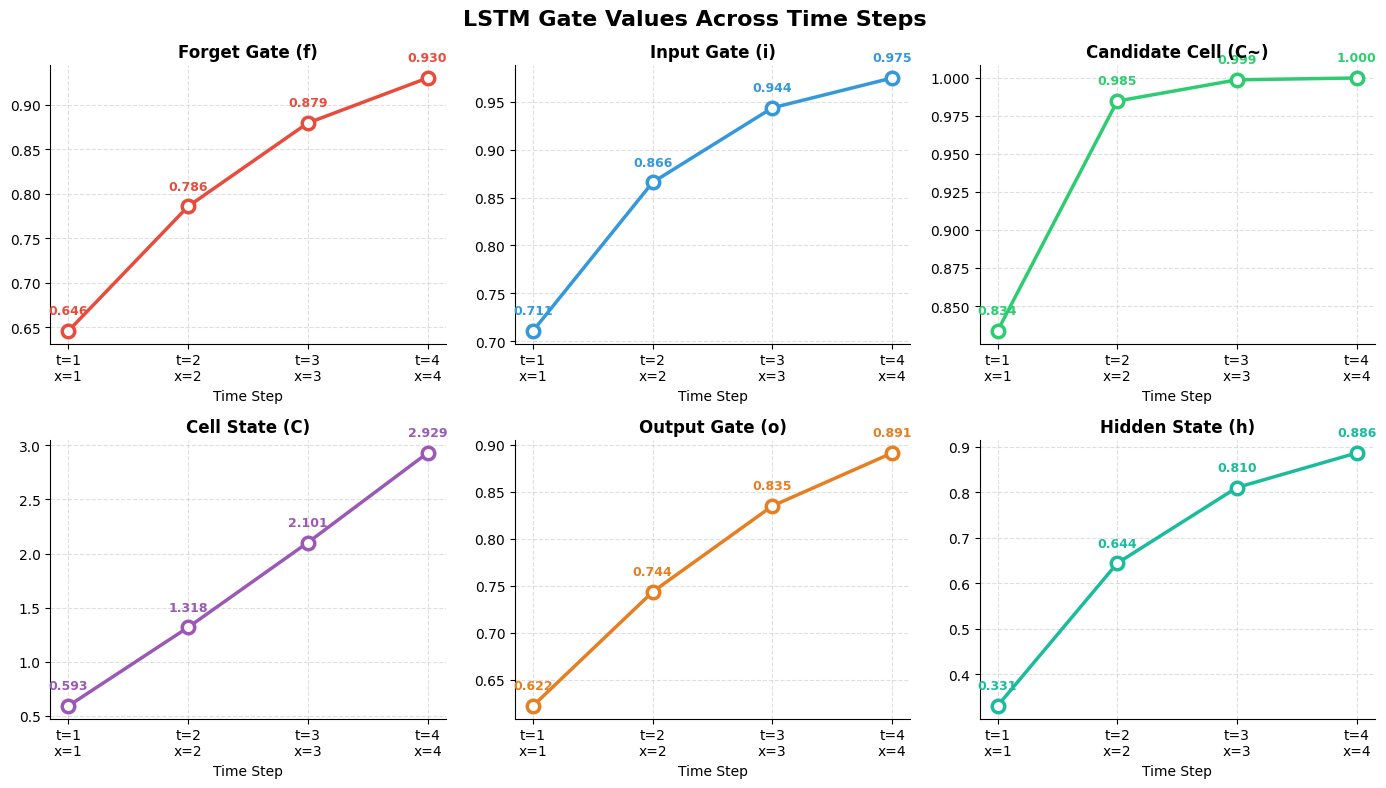

In [9]:
h, C = 0.0, 0.0
history = {'f': [], 'i': [], 'C_tilde': [], 'C': [], 'o': [], 'h': []}

for x in inputs:
    h, C, gates = lstm_step(x, h, C)
    history['f'].append(gates['f'])
    history['i'].append(gates['i'])
    history['C_tilde'].append(gates['C_tilde'])
    history['C'].append(gates['C_new'])
    history['o'].append(gates['o'])
    history['h'].append(gates['h_new'])

timesteps = [1, 2, 3, 4]
xlabels   = [f't={t}\nx={x}' for t, x in zip(timesteps, inputs)]

configs = [
    ('f',       'Forget Gate (f)',     '#e74c3c'),
    ('i',       'Input Gate (i)',      '#3498db'),
    ('C_tilde', 'Candidate Cell (C~)', '#2ecc71'),
    ('C',       'Cell State (C)',      '#9b59b6'),
    ('o',       'Output Gate (o)',     '#e67e22'),
    ('h',       'Hidden State (h)',    '#1abc9c'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('LSTM Gate Values Across Time Steps', fontsize=16, fontweight='bold')

for ax, (key, title, color) in zip(axes.flat, configs):
    values = history[key]
    ax.plot(timesteps, values, 'o-', color=color, linewidth=2.5,
            markersize=9, markerfacecolor='white', markeredgewidth=2.5)
    for t, v in zip(timesteps, values):
        ax.annotate(f'{v:.3f}', (t, v), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=9,
                    color=color, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Step', fontsize=10)
    ax.set_xticks(timesteps)
    ax.set_xticklabels(xlabels)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 10. Reusable LSTMFromScratch Class

In [11]:
class LSTMFromScratch:
    """
    Single-unit LSTM from scratch using NumPy.
    Matches the numerical example from the PDF exactly.
    """

    def __init__(self,
                 Wf=0.5, Uf=0.6, bf=0.1,
                 Wi=0.7, Ui=0.8, bi=0.2,
                 Wc=0.9, Uc=1.0, bc=0.3,
                 Wo=0.4, Uo=0.5, bo=0.1,
                 Wy=4.0, by=0.2):
        self.p = dict(
            Wf=Wf, Uf=Uf, bf=bf,
            Wi=Wi, Ui=Ui, bi=bi,
            Wc=Wc, Uc=Uc, bc=bc,
            Wo=Wo, Uo=Uo, bo=bo,
            Wy=Wy, by=by
        )

    def _sigmoid(self, x): return 1 / (1 + np.exp(-x))
    def _tanh(self, x):    return np.tanh(x)

    def forward(self, sequence, verbose=False):
        p = self.p
        h, C = 0.0, 0.0

        for t, x in enumerate(sequence, start=1):
            f       = self._sigmoid(p['Wf']*x + p['Uf']*h + p['bf'])
            i       = self._sigmoid(p['Wi']*x + p['Ui']*h + p['bi'])
            C_tilde = self._tanh(   p['Wc']*x + p['Uc']*h + p['bc'])
            C       = f * C + i * C_tilde
            o       = self._sigmoid(p['Wo']*x + p['Uo']*h + p['bo'])
            h       = o * self._tanh(C)

            if verbose:
                print(f"t={t} | x={x} | f={f:.4f} | i={i:.4f} | "
                      f"C~={C_tilde:.4f} | C={C:.4f} | o={o:.4f} | h={h:.4f}")

        y_pred = p['Wy'] * h + p['by']
        return y_pred, h, C


# ── Run ───────────────────────────────────────────────
lstm = LSTMFromScratch()
y_pred, h_final, C_final = lstm.forward([1, 2, 3, 4], verbose=True)

print(f"\n" + "="*50)
print(f"  Predicted : y_hat = {y_pred:.4f}")
print(f"  Actual    : 4")
print("="*50)

t=1 | x=1 | f=0.6457 | i=0.7109 | C~=0.8337 | C=0.5927 | o=0.6225 | h=0.3310
t=2 | x=2 | f=0.7856 | i=0.8659 | C~=0.9846 | C=1.3182 | o=0.7437 | h=0.6443
t=3 | x=3 | f=0.8794 | i=0.9435 | C~=0.9986 | C=2.1014 | o=0.8351 | h=0.8105
t=4 | x=4 | f=0.9300 | i=0.9746 | C~=0.9998 | C=2.9287 | o=0.8914 | h=0.8863

  Predicted : y_hat = 3.7453
  Actual    : 4
